Overshoot: 10.62%
Settling Time: 8.93 s
Poles: [-0.33251681+1.60752974j -0.33251681-1.60752974j -0.83496638+0.j        ]


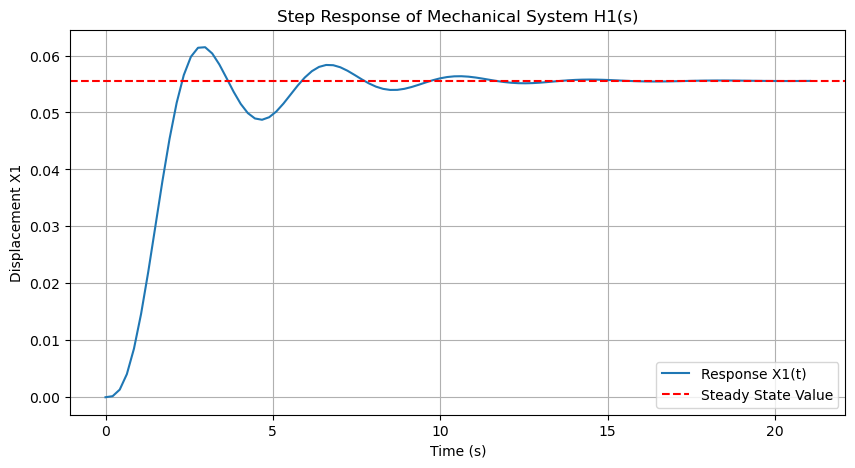

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Define the transfer function H1(s) = 1 / (8s^3 + 12s^2 + 26s + 18)
num = [1]
den = [8, 12, 26, 18]
sys = signal.TransferFunction(num, den)

# 1. Generate Step Response
t, y = signal.step(sys)
y_final = num[0] / den[-1]  # Steady-state value for a unit step input

# Plot Step Response
plt.figure(figsize=(10, 5))
plt.plot(t, y, label='Response X1(t)')
plt.axhline(y_final, color='r', linestyle='--', label='Steady State Value')
plt.title('Step Response of Mechanical System H1(s)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement X1')
plt.grid(True)
plt.legend()

# 2. Calculate Overshoot and Settling Time
peak_val = np.max(y)
overshoot_pct = max(0, (peak_val - y_final) / y_final * 100)

# Settling time (2%): last time the response exits error band
upper_bound = y_final * 1.02
lower_bound = y_final * 0.98
outside_indices = np.where((y > upper_bound) | (y < lower_bound))[0]
settling_time = t[outside_indices[-1]] if len(outside_indices) > 0 else 0

# 3. Generate Pole-Zero Map
poles = np.roots(den)
print(f"Overshoot: {overshoot_pct:.2f}%")
print(f"Settling Time: {settling_time:.2f} s")
print(f"Poles: {poles}")